# Milestone 3 — GridFM v0.1 and the Physics-Informed Loss

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds
from gridfm.model import GridFMv01, gridfm_loss, count_parameters
from torch_geometric.loader import DataLoader

PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "m3"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

model = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
print(model)
print("\ntrainable parameters: %.0fk (thesis v0.1: 7,400k)" % (count_parameters(model) / 1e3))

GridFMv01(
  (embed): Linear(in_features=9, out_features=128, bias=True)
  (convs): ModuleList(
    (0-3): 4 x TransformerConv(128, 32, heads=4)
  )
  (act): ReLU()
  (drop): Dropout(p=0.1, inplace=False)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)

trainable parameters: 284k (thesis v0.1: 7,400k)


## A forward pass

In [2]:
train30 = ds.load_processed(PROC_DIR, "case30", "train")
val30 = ds.load_processed(PROC_DIR, "case30", "val")
batch = next(iter(DataLoader(train30, batch_size=64, shuffle=False)))
x_masked, mask = ds.random_mask(batch.x, generator=torch.Generator().manual_seed(0))
with torch.no_grad():
    pred = model(x_masked, batch.edge_index, batch.edge_attr)
print("input  x_masked:", tuple(x_masked.shape), "(64 case30 graphs batched: 1920 buses)")
print("output pred    :", tuple(pred.shape))

input  x_masked: (1920, 9) (64 case30 graphs batched: 1920 buses)
output pred    : (1920, 6)


## The loss: L = 0.01 · L_MSE + 0.99 · L_PBE

In [3]:
# Check 1: ground truth as "prediction"
_, parts_truth = gridfm_loss(batch.x[:, :6].clone(), batch.x, mask,
                             batch.ybus_index, batch.ybus_g, batch.ybus_b)
# Check 2: untrained model
pred = model(x_masked, batch.edge_index, batch.edge_attr)
loss, parts_rand = gridfm_loss(pred, batch.x, mask,
                               batch.ybus_index, batch.ybus_g, batch.ybus_b)
print("                       MSE          PBE")
print("ground truth      %.2e     %.2e   <- physics exactly satisfied" %
      (parts_truth["mse"], parts_truth["pbe"]))
print("untrained model   %.2e     %.2e   <- random guesses violate Kirchhoff badly" %
      (parts_rand["mse"], parts_rand["pbe"]))

# Check 3: gradient flow
loss.backward()
n_dead = sum(1 for p in model.parameters() if p.grad is None or p.grad.abs().sum() == 0)
print("parameter tensors without gradient: %d / %d" % (n_dead, len(list(model.parameters()))))

                       MSE          PBE
ground truth      0.00e+00     9.80e-12   <- physics exactly satisfied
untrained model   5.04e+00     6.01e+04   <- random guesses violate Kirchhoff badly
parameter tensors without gradient: 0 / 42


## Sanity Check

330 steps in 0.4 min


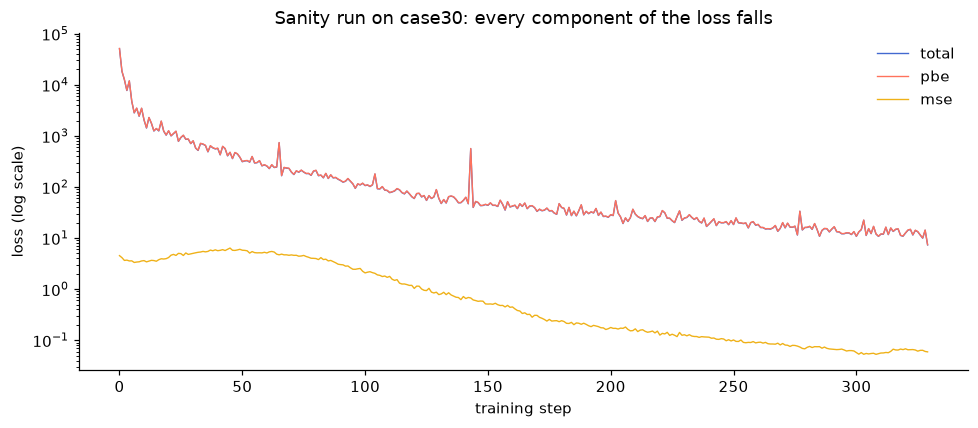

In [4]:
import time
torch.manual_seed(SEED)
model = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
opt = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.999))
loader = DataLoader(train30, batch_size=64, shuffle=True)

hist = {"step": [], "mse": [], "pbe": [], "total": []}
t0, step = time.time(), 0
for epoch in range(15):
    for b in loader:
        xm, m = ds.random_mask(b.x)
        pred = model(xm, b.edge_index, b.edge_attr)
        loss, parts = gridfm_loss(pred, b.x, m, b.ybus_index, b.ybus_g, b.ybus_b)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        for k in ["mse", "pbe", "total"]:
            hist[k].append(parts[k])
        hist["step"].append(step); step += 1
print("%d steps in %.1f min" % (step, (time.time() - t0) / 60))

fig, ax = plt.subplots(figsize=(9, 4))
for k, c in zip(["total", "pbe", "mse"], ["#4269D0", "#FF725C", "#EFB118"]):
    ax.plot(hist["step"], hist[k], lw=0.9, color=c, label=k)
ax.set_yscale("log")
ax.set(xlabel="training step", ylabel="loss (log scale)",
       title="Sanity run on case30: every component of the loss falls")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_sanity_training.png", bbox_inches="tight")
plt.show()

## What the model can already reconstruct (after 6 epochs on one grid)

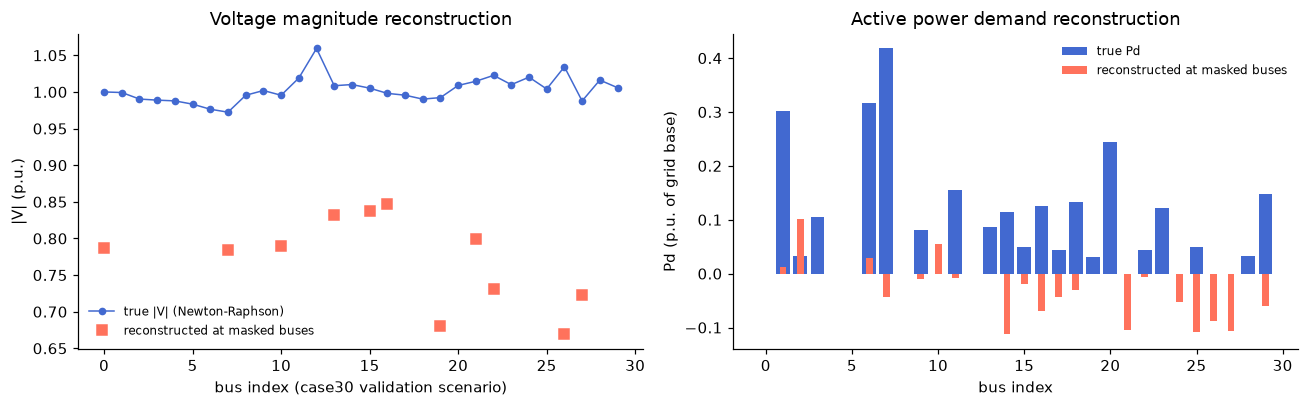

masked |V| reconstruction error after the sanity run: mean 0.2320 p.u., worst 0.3652 p.u.


In [5]:
model.eval()
g = val30[0]
xm, m = ds.random_mask(g.x, generator=torch.Generator().manual_seed(7))
with torch.no_grad():
    pred = model(xm, g.edge_index, g.edge_attr)

vm_true = g.x[:, 4].numpy()
vm_masked_idx = np.where(m[:, 4].numpy())[0]
vm_pred = pred[:, 4].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(vm_true, "o-", color="#4269D0", lw=1, ms=4, label="true |V| (Newton-Raphson)")
axes[0].plot(vm_masked_idx, vm_pred[vm_masked_idx], "s", color="#FF725C", ms=6,
             label="reconstructed at masked buses")
axes[0].set(xlabel="bus index (case30 validation scenario)", ylabel="|V| (p.u.)",
            title="Voltage magnitude reconstruction")
axes[0].legend(frameon=False, fontsize=8)

pd_true = g.x[:, 0].numpy()
pd_masked_idx = np.where(m[:, 0].numpy())[0]
axes[1].bar(np.arange(len(pd_true)), pd_true, color="#4269D0", label="true Pd")
axes[1].bar(pd_masked_idx, pred[pd_masked_idx, 0].numpy(), width=0.4,
            color="#FF725C", label="reconstructed at masked buses")
axes[1].set(xlabel="bus index", ylabel="Pd (p.u. of grid base)",
            title="Active power demand reconstruction")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_reconstruction_teaser.png", bbox_inches="tight")
plt.show()

err = np.abs(vm_pred[vm_masked_idx] - vm_true[vm_masked_idx])
print("masked |V| reconstruction error after the sanity run: mean %.4f p.u., worst %.4f p.u." %
      (err.mean(), err.max()))